# Modelo Basado en Reglas para Deteccion de Fraude Transaccional

Este notebook construye una linea base interpretable basada en reglas para compararla con los modelos de Machine Learning ya implementados en el proyecto. El flujo reutiliza las variables generadas por `notebooks/2_ingenieria_caracteristicas.ipynb`, respeta exactamente las particiones temporales usadas en los notebooks de modelamiento y fija el umbral exclusivamente con el conjunto de validacion.

**Objetivos del notebook**

- Cargar el dataset final de modelamiento derivado de la ingenieria de caracteristicas.
- Inspeccionar las variables disponibles antes de definir reglas.
- Construir un puntaje interpretable a partir de reglas binarias transaccionales.
- Convertir ese puntaje en un clasificador binario usando un threshold optimizado solo en validacion.
- Evaluar el resultado final en test con las mismas metricas reportadas en `notebooks/4_model_selection_cards.ipynb`.
- Comparar el baseline basado en reglas frente a los modelos de Machine Learning ya evaluados en el proyecto.


# Introduccion

El enfoque basado en reglas busca representar patrones de fraude que resultan faciles de interpretar para analistas y comites de riesgo. A diferencia de los modelos supervisados complejos, este baseline no aprende fronteras no lineales ni combinaciones de alta dimensionalidad; en su lugar, agrega evidencia de riesgo mediante un conjunto reducido de reglas comprensibles.

Metodologicamente, el notebook sigue dos restricciones estrictas:

1. Las reglas se construyen exclusivamente a partir de variables ya disponibles en el dataset final de modelamiento.
2. El conjunto `test` se utiliza una unica vez para la evaluacion final. La seleccion del threshold se realiza unicamente en `validation`.

Adicionalmente, se excluyen del baseline las variables de frecuencia global calculadas sobre todo el dataset, dado que ese tipo de agregaciones puede introducir leakage temporal cuando se usan sin reestimacion por split.


# Carga de librerias


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = next((path for path in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents] if (path / "src").exists()), NOTEBOOK_DIR)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.rule_based_model import (
    DEFAULT_TEMPORAL_SPLIT,
    GLOBAL_LEAKAGE_COLUMNS,
    TARGET_COLUMN,
    build_rule_threshold_table,
    compare_with_ml_test,
    compare_with_ml_validation,
    describe_rule_set,
    fit_rule_artifacts,
    get_dataset_overview,
    load_rule_split,
    score_rule_frame,
    select_best_threshold,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")


ModuleNotFoundError: No module named 'src'

# Carga de datos procesados


In [ ]:
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"

MODELING_DATASET_PATH = DATA_PROCESSED_DIR / "transactions_modeling.parquet"
SNAPSHOT_DATASET_PATH = DATA_PROCESSED_DIR / "user_card_snapshot_features.parquet"
SPLIT_SUMMARY_PATH = TABLES_DIR / "split_summary.csv"
MODEL_RESULTS_PATH = TABLES_DIR / "model_experiment_results.csv"
FINAL_COMPARISON_PATH = TABLES_DIR / "final_model_comparison.csv"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

required_paths = {
    "Dataset de modelamiento": MODELING_DATASET_PATH,
    "Snapshot usuario-tarjeta": SNAPSHOT_DATASET_PATH,
    "Resumen de splits": SPLIT_SUMMARY_PATH,
    "Resultados de validacion ML": MODEL_RESULTS_PATH,
    "Comparacion final ML en test": FINAL_COMPARISON_PATH,
}

missing_paths = [name for name, path in required_paths.items() if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f"Faltan archivos requeridos para este notebook: {missing_paths}")

generated_feature_files = pd.DataFrame(
    {
        "artifact_name": [
            "transactions_modeling.parquet",
            "user_card_snapshot_features.parquet",
        ],
        "path": [
            str(MODELING_DATASET_PATH),
            str(SNAPSHOT_DATASET_PATH),
        ],
        "exists": [
            MODELING_DATASET_PATH.exists(),
            SNAPSHOT_DATASET_PATH.exists(),
        ],
        "size_mb": [
            round(MODELING_DATASET_PATH.stat().st_size / 1024**2, 2),
            round(SNAPSHOT_DATASET_PATH.stat().st_size / 1024**2, 2),
        ],
    }
)
display(generated_feature_files)

split_summary = pd.read_csv(SPLIT_SUMMARY_PATH)
display(split_summary)

display(
    Markdown(
        f'''
        **Particiones temporales reutilizadas**

        - Train: `{DEFAULT_TEMPORAL_SPLIT.train_start}` a `{DEFAULT_TEMPORAL_SPLIT.train_end}`
        - Validation: `{DEFAULT_TEMPORAL_SPLIT.validation_start}` a `{DEFAULT_TEMPORAL_SPLIT.validation_end}`
        - Test: `{DEFAULT_TEMPORAL_SPLIT.test_start}` a `{DEFAULT_TEMPORAL_SPLIT.test_end}`
        - Excluded: `{", ".join(DEFAULT_TEMPORAL_SPLIT.excluded_periods)}`
        '''
    )
)


,artifact_name,path,exists,size_mb
0,transactions_modeling.parquet,C:\Users\cecor\OneDrive - Universidad Nacional...,True,3287.62
1,user_card_snapshot_features.parquet,C:\Users\cecor\OneDrive - Universidad Nacional...,True,2.19


,split,n_rows,n_positive,fraud_rate,start_period,end_period
0,train,20604847,25179,0.001222,1991-01,2017-12
1,validation,1721615,2491,0.001447,2018-01,2018-12
2,test,1435413,2087,0.001454,2019-01,2019-10
3,excluded,625025,0,0.000000,2019-11,2020-02



        **Particiones temporales reutilizadas**

        - Train: `1991-01` a `2017-12`
        - Validation: `2018-01` a `2018-12`
        - Test: `2019-01` a `2019-10`
        - Excluded: `2019-11, 2019-12, 2020-01, 2020-02`
        

# Revision de variables disponibles


In [ ]:
dataset_overview = get_dataset_overview(MODELING_DATASET_PATH)

available_rule_columns_df = pd.DataFrame({"safe_rule_columns": dataset_overview["safe_rule_columns"]})
excluded_global_columns_df = pd.DataFrame({"excluded_global_columns": dataset_overview["excluded_global_columns"]})

print(f"Numero total de columnas en transactions_modeling.parquet: {dataset_overview['n_columns']}")
print(f"Numero de columnas seguras consideradas por el baseline: {len(dataset_overview['safe_rule_columns'])}")
print(f"Numero de columnas excluidas por posible leakage temporal: {len(dataset_overview['excluded_global_columns'])}")

display(available_rule_columns_df)
display(excluded_global_columns_df)


Numero total de columnas en transactions_modeling.parquet: 217
Numero de columnas seguras consideradas por el baseline: 40
Numero de columnas excluidas por posible leakage temporal: 20


,safe_rule_columns
0,datetime
1,amount_is_negative
2,new_state_for_card_flag
3,year_month
4,new_mcc_for_card_flag
5,long_inactivity_90d_flag
6,online_first_time_for_card_flag
7,first_transaction_flag
8,merchant_city
9,uc_activity_spike_3m_vs_12m_flag


,excluded_global_columns
0,amount_above_global_p90_flag
1,amount_above_global_p95_flag
2,amount_above_global_p99_flag
3,mcc_frequency_global
4,mcc_tx_count_global
5,merchant_city_frequency_global
6,merchant_city_tx_count_global
7,merchant_frequency_global
8,merchant_state_frequency_global
9,merchant_state_tx_count_global


# Definicion de reglas


In [ ]:
artifacts = fit_rule_artifacts(MODELING_DATASET_PATH)
validation_frame = load_rule_split(MODELING_DATASET_PATH, "validation")
test_frame = load_rule_split(MODELING_DATASET_PATH, "test")

rule_summary_validation = describe_rule_set(validation_frame, artifacts)
risky_mccs_train = artifacts.mcc_risk_table.copy()

risky_mccs_train.to_csv(TABLES_DIR / "rule_based_risky_mccs_train.csv", index=False)
rule_summary_validation.to_csv(TABLES_DIR / "rule_based_rule_summary_validation.csv", index=False)

display(
    Markdown(
        f'''
        **Criterio general de las reglas**

        El baseline activa evidencia de fraude cuando la transaccion presenta desalineamientos frente al historial de la tarjeta o del usuario. En esta implementacion se consolidaron `{rule_summary_validation.attrs['n_rules']}` reglas.

        **Variables globales excluidas**

        Se excluyeron `{len(dataset_overview['excluded_global_columns'])}` variables de frecuencia global para evitar usar agregaciones calculadas con informacion futura respecto a `train`.
        '''
    )
)

display(rule_summary_validation)
display(risky_mccs_train[risky_mccs_train["selected_for_rule"] == 1].head(15))



        **Criterio general de las reglas**

        El baseline activa evidencia de fraude cuando la transaccion presenta desalineamientos frente al historial de la tarjeta o del usuario. En esta implementacion se consolidaron `8` reglas.

        **Variables globales excluidas**

        Se excluyeron `20` variables de frecuencia global para evitar usar agregaciones calculadas con informacion futura respecto a `train`.
        

,rule_name,description,trigger_rate,trigger_count
0,rule_operational_anomaly,"Anomalias operativas como montos negativos, ce...",0.179339,308753
1,rule_high_amount_deviation,Monto alto respecto al comportamiento historic...,0.053613,92301
2,rule_velocity_spike,Alta velocidad/frecuencia intradia o pico de a...,0.046279,79675
3,rule_new_merchant_or_category,Comercio o MCC no observado previamente para l...,0.027949,48118
4,rule_unusual_location,"Ciudad, estado o codigo postal no observado pr...",0.023836,41036
5,rule_high_risk_mcc,MCC con elevada tasa historica de fraude en tr...,0.002363,4069
6,rule_inactivity_plus_change,Reaparicion tras inactividad combinada con cam...,0.000065,112
7,rule_online_channel_risk,Transaccion online con evidencia de cambio o n...,0.000060,104


,mcc,tx_count,fraud_count,fraud_rate,lift_vs_train,eligible_high_risk,selected_for_rule
0,5045,4216,349,0.082780,67.741645,1,1
1,5732,10752,839,0.078032,63.856281,1,1
2,5816,4309,296,0.068693,56.214213,1,1
3,5094,7930,449,0.056620,46.334456,1,1
4,5712,6011,291,0.048411,39.616598,1,1
5,4112,3581,158,0.044122,36.106358,1,1
6,5533,1885,59,0.031300,25.613656,1,1
7,4131,3511,79,0.022501,18.413111,1,1
8,5941,1827,41,0.022441,18.364378,1,1
9,4511,3887,84,0.021610,17.684617,1,1


# Modelo basado en puntaje

El puntaje del baseline se define como la proporcion de reglas activadas en cada transaccion:

\[
\text{rule\_score}_i = \frac{\sum_{r=1}^{R} \mathbb{1}(\text{regla } r \text{ activa en } i)}{R}
\]

Este puntaje no reemplaza a la decision binaria final, pero resume de forma interpretable cuanta evidencia de riesgo acumula una transaccion. Posteriormente, ese puntaje se transforma en una prediccion binaria mediante un threshold optimizado en validacion.


In [ ]:
validation_rules, validation_scores = score_rule_frame(validation_frame, artifacts)
test_rules, test_scores = score_rule_frame(test_frame, artifacts)

validation_score_summary = (
    pd.DataFrame(
        {
            "rule_score": validation_scores,
            "rules_triggered": validation_rules.sum(axis=1),
            TARGET_COLUMN: validation_frame[TARGET_COLUMN].to_numpy(),
        }
    )
    .groupby(TARGET_COLUMN)
    .agg(
        n_obs=("rule_score", "size"),
        mean_score=("rule_score", "mean"),
        median_score=("rule_score", "median"),
        mean_rules_triggered=("rules_triggered", "mean"),
        p90_score=("rule_score", lambda s: float(s.quantile(0.90))),
        max_score=("rule_score", "max"),
    )
    .reset_index()
)

display(validation_score_summary)


,is_fraud,n_obs,mean_score,median_score,mean_rules_triggered,p90_score,max_score
0,0,1719124,0.041391,0.00,0.331125,0.125,0.875
1,1,2491,0.247039,0.25,1.976315,0.375,0.625


# Modelo basado en reglas binarias

La prediccion binaria se obtiene comparando el puntaje del baseline con un threshold fijo. Como el score corresponde a la proporcion de reglas activadas, thresholds mayores exigen mas evidencia simultanea antes de marcar una transaccion como fraude.


# Optimizacion de umbral en validacion


In [ ]:
threshold_table_validation = build_rule_threshold_table(
    validation_frame[TARGET_COLUMN],
    validation_scores,
    n_rules=validation_rules.shape[1],
)
best_threshold_row = select_best_threshold(threshold_table_validation, criterion="f1")
best_threshold = float(best_threshold_row["threshold"])
min_rules_required = int(best_threshold_row["min_rules_required"])

threshold_table_validation.to_csv(TABLES_DIR / "rule_based_threshold_optimization_validation.csv", index=False)
threshold_table_validation.to_excel(TABLES_DIR / "rule_based_threshold_optimization_validation.xlsx", index=False)

threshold_columns_order = [
    "threshold",
    "min_rules_required",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "pr_auc",
    "roc_auc",
    "tp",
    "fp",
    "tn",
    "fn",
    "n_predicted_positive",
]

display(
    Markdown(
        f'''
        **Threshold seleccionado en validacion**

        - Threshold: `{best_threshold:.2f}`
        - Reglas minimas activadas: `{min_rules_required}`
        - Precision: `{best_threshold_row['precision']:.6f}`
        - Recall: `{best_threshold_row['recall']:.6f}`
        - F1-score: `{best_threshold_row['f1']:.6f}`
        - PR-AUC: `{best_threshold_row['pr_auc']:.6f}`
        - ROC-AUC: `{best_threshold_row['roc_auc']:.6f}`
        '''
    )
)
display(threshold_table_validation[threshold_columns_order].head(20))
display(threshold_table_validation.sort_values(["f1", "recall", "precision"], ascending=[False, False, False]).head(10))



        **Threshold seleccionado en validacion**

        - Threshold: `0.26`
        - Reglas minimas activadas: `3`
        - Precision: `0.052994`
        - Recall: `0.240867`
        - F1-score: `0.086875`
        - PR-AUC: `0.025651`
        - ROC-AUC: `0.936551`
        

,threshold,min_rules_required,accuracy,precision,recall,f1,pr_auc,roc_auc,tp,fp,tn,fn,n_predicted_positive
0,0.01,1,0.723112,0.005198,1.000000,0.010343,0.025651,0.936551,2491,476695,1242429,0,479186
1,0.02,1,0.723112,0.005198,1.000000,0.010343,0.025651,0.936551,2491,476695,1242429,0,479186
2,0.03,1,0.723112,0.005198,1.000000,0.010343,0.025651,0.936551,2491,476695,1242429,0,479186
3,0.04,1,0.723112,0.005198,1.000000,0.010343,0.025651,0.936551,2491,476695,1242429,0,479186
4,0.05,1,0.723112,0.005198,1.000000,0.010343,0.025651,0.936551,2491,476695,1242429,0,479186
5,0.06,1,0.723112,0.005198,1.000000,0.010343,0.025651,0.936551,2491,476695,1242429,0,479186
6,0.07,1,0.723112,0.005198,1.000000,0.010343,0.025651,0.936551,2491,476695,1242429,0,479186
7,0.08,1,0.723112,0.005198,1.000000,0.010343,0.025651,0.936551,2491,476695,1242429,0,479186
8,0.09,1,0.723112,0.005198,1.000000,0.010343,0.025651,0.936551,2491,476695,1242429,0,479186
9,0.10,1,0.723112,0.005198,1.000000,0.010343,0.025651,0.936551,2491,476695,1242429,0,479186


,threshold,n_obs,n_positive,positive_rate,precision,recall,f1,pr_auc,balanced_accuracy,roc_auc,tn,fp,fn,tp,accuracy,n_predicted_positive,min_rules_required
25,0.26,1721615,2491,0.001447,0.052994,0.240867,0.086875,0.025651,0.617315,0.936551,1708402,10722,1891,600,0.992674,11322,3
26,0.27,1721615,2491,0.001447,0.052994,0.240867,0.086875,0.025651,0.617315,0.936551,1708402,10722,1891,600,0.992674,11322,3
27,0.28,1721615,2491,0.001447,0.052994,0.240867,0.086875,0.025651,0.617315,0.936551,1708402,10722,1891,600,0.992674,11322,3
28,0.29,1721615,2491,0.001447,0.052994,0.240867,0.086875,0.025651,0.617315,0.936551,1708402,10722,1891,600,0.992674,11322,3
29,0.30,1721615,2491,0.001447,0.052994,0.240867,0.086875,0.025651,0.617315,0.936551,1708402,10722,1891,600,0.992674,11322,3
30,0.31,1721615,2491,0.001447,0.052994,0.240867,0.086875,0.025651,0.617315,0.936551,1708402,10722,1891,600,0.992674,11322,3
31,0.32,1721615,2491,0.001447,0.052994,0.240867,0.086875,0.025651,0.617315,0.936551,1708402,10722,1891,600,0.992674,11322,3
32,0.33,1721615,2491,0.001447,0.052994,0.240867,0.086875,0.025651,0.617315,0.936551,1708402,10722,1891,600,0.992674,11322,3
33,0.34,1721615,2491,0.001447,0.052994,0.240867,0.086875,0.025651,0.617315,0.936551,1708402,10722,1891,600,0.992674,11322,3
34,0.35,1721615,2491,0.001447,0.052994,0.240867,0.086875,0.025651,0.617315,0.936551,1708402,10722,1891,600,0.992674,11322,3


# Evaluacion final en test


In [ ]:
final_metrics_test = build_rule_threshold_table(
    test_frame[TARGET_COLUMN],
    test_scores,
    n_rules=test_rules.shape[1],
    thresholds=np.array([best_threshold]),
).iloc[0]

y_test = test_frame[TARGET_COLUMN].to_numpy(dtype=int)
y_test_pred = (test_scores >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()
classification_report_test = pd.DataFrame(
    classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
).T

final_metrics_test_row = {
    "model_name": "rule_based_binary",
    "feature_subset": "interpretable_rules",
    "balancing_strategy": "none",
    "n_rules": int(test_rules.shape[1]),
    "threshold_from_validation": float(best_threshold),
    "min_rules_required": int(final_metrics_test["min_rules_required"]),
    "accuracy": float(final_metrics_test["accuracy"]),
    "precision": float(final_metrics_test["precision"]),
    "recall": float(final_metrics_test["recall"]),
    "f1_score": float(final_metrics_test["f1"]),
    "roc_auc": float(final_metrics_test["roc_auc"]),
    "pr_auc": float(final_metrics_test["pr_auc"]),
    "tp": int(tp),
    "fp": int(fp),
    "tn": int(tn),
    "fn": int(fn),
    "test_rows_used": int(final_metrics_test["n_obs"]),
    "test_positive_rows": int(final_metrics_test["n_positive"]),
}

final_metrics_test_df = pd.DataFrame([final_metrics_test_row])
confusion_matrix_df = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Actual_0", "Actual_1"],
    columns=["Pred_0", "Pred_1"],
)

final_metrics_test_df.to_csv(TABLES_DIR / "rule_based_metrics_test.csv", index=False)
final_metrics_test_df.to_excel(TABLES_DIR / "rule_based_metrics_test.xlsx", index=False)
classification_report_test.to_csv(TABLES_DIR / "rule_based_classification_report_test.csv")
confusion_matrix_df.to_csv(TABLES_DIR / "rule_based_confusion_matrix_test.csv")

display(final_metrics_test_df)
display(confusion_matrix_df)
display(classification_report_test)


,model_name,feature_subset,balancing_strategy,n_rules,threshold_from_validation,min_rules_required,accuracy,precision,recall,f1_score,roc_auc,pr_auc,tp,fp,tn,fn,test_rows_used,test_positive_rows
0,rule_based_binary,interpretable_rules,none,8,0.26,3,0.993126,0.05553,0.23287,0.089676,0.937028,0.027003,486,8266,1425060,1601,1435413,2087


,Pred_0,Pred_1
Actual_0,1425060,8266
Actual_1,1601,486


,precision,recall,f1-score,support
0,0.998878,0.994233,0.996550,1.433326e+06
1,0.055530,0.232870,0.089676,2.087000e+03
accuracy,0.993126,0.993126,0.993126,9.931260e-01
macro avg,0.527204,0.613552,0.543113,1.435413e+06
weighted avg,0.997506,0.993126,0.995231,1.435413e+06


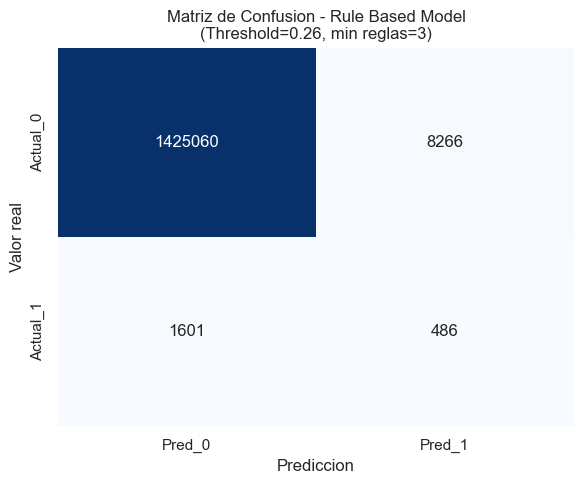

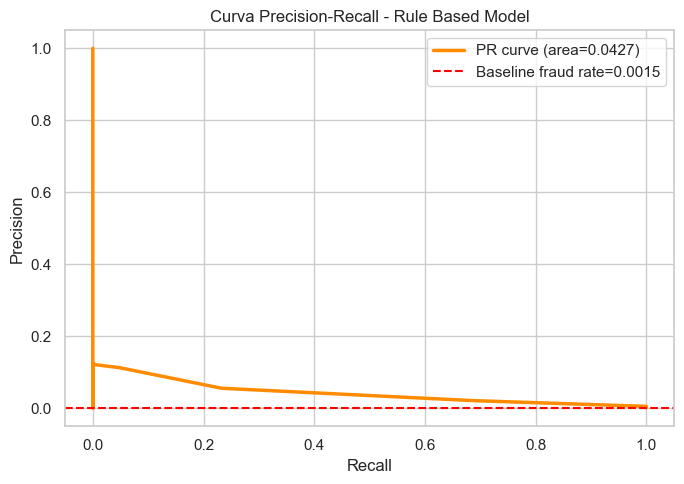

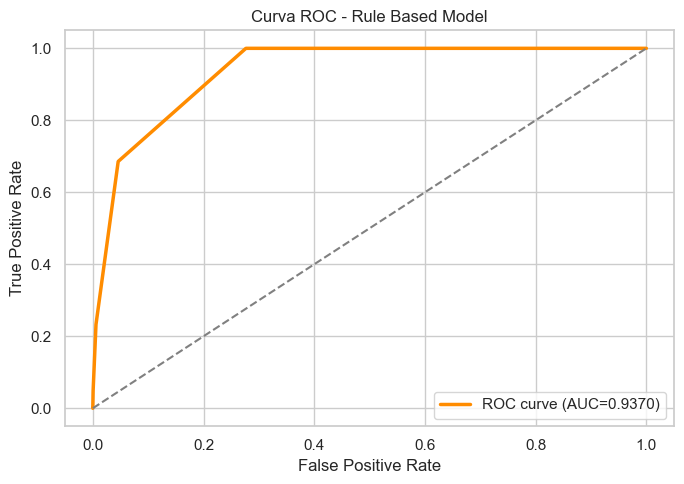

In [ ]:
# Matriz de confusion
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(confusion_matrix_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title(f"Matriz de Confusion - Rule Based Model\n(Threshold={best_threshold:.2f}, min reglas={min_rules_required})")
ax.set_xlabel("Prediccion")
ax.set_ylabel("Valor real")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_rule_based_model.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# Curva Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_scores)
pr_curve_area = auc(recall_curve, precision_curve)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_curve, precision_curve, color="darkorange", lw=2.5, label=f"PR curve (area={pr_curve_area:.4f})")
ax.axhline(y=float(y_test.mean()), color="red", linestyle="--", lw=1.5, label=f"Baseline fraud rate={y_test.mean():.4f}")
ax.set_title("Curva Precision-Recall - Rule Based Model")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="best")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "precision_recall_curve_rule_based_model.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, test_scores)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="darkorange", lw=2.5, label=f"ROC curve (AUC={final_metrics_test['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1.5)
ax.set_title("Curva ROC - Rule Based Model")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_curve_rule_based_model.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


# Comparacion contra modelos de Machine Learning


In [ ]:
validation_comparison = compare_with_ml_validation(MODEL_RESULTS_PATH, best_threshold_row.to_dict())
test_comparison = compare_with_ml_test(FINAL_COMPARISON_PATH, final_metrics_test_row)

validation_comparison.to_csv(TABLES_DIR / "rule_based_vs_ml_validation.csv", index=False)
test_comparison.to_csv(TABLES_DIR / "rule_based_vs_ml_test.csv", index=False)

rule_validation_rank = int(validation_comparison.index[validation_comparison["model_name"] == "rule_based_binary"][0]) + 1
rule_test_rank = int(test_comparison.index[test_comparison["model_name"] == "rule_based_binary"][0]) + 1

best_validation_ml = validation_comparison[validation_comparison["model_name"] != "rule_based_binary"].iloc[0]
best_test_ml = test_comparison[test_comparison["model_name"] != "rule_based_binary"].iloc[0]

display(
    Markdown(
        f'''
        **Alcance de la comparacion**

        - `validation`: comparacion amplia contra las mejores corridas por familia reportadas en `model_experiment_results.csv`, incluyendo modelos como SVC, Random Forest, MLP, XGBoost y otros.
        - `test`: comparacion final contra los modelos reentrenados y evaluados en `notebooks/4_model_selection_cards.ipynb`.
        '''
    )
)

display(validation_comparison.head(15))
display(test_comparison)



        **Alcance de la comparacion**

        - `validation`: comparacion amplia contra las mejores corridas por familia reportadas en `model_experiment_results.csv`, incluyendo modelos como SVC, Random Forest, MLP, XGBoost y otros.
        - `test`: comparacion final contra los modelos reentrenados y evaluados en `notebooks/4_model_selection_cards.ipynb`.
        

,model_name,feature_subset,balancing_strategy,pr_auc,roc_auc,recall,precision,f1,threshold_used,tn,fp,fn,tp,source,comparison_scope,accuracy
0,svc_rbf,top_25,class_weight_balanced,0.701137,0.975154,0.939783,0.478243,0.633902,0.42,34955.0,2554.0,150.0,2341.0,ml_validation,validation,0.932400
1,xgboost_calibrated,top_100,scale_pos_weight,0.688636,0.988713,0.686070,0.587487,0.632963,0.64,116309.0,1200.0,782.0,1709.0,ml_validation,validation,0.983483
2,torch_mlp,top_100,none,0.661894,0.983656,0.598153,0.608412,0.603239,0.94,116550.0,959.0,1001.0,1490.0,ml_validation,validation,0.983667
3,xgboost,top_100,scale_pos_weight_manual,0.638918,0.989186,0.578483,0.613975,0.595701,0.41,196603.0,906.0,1050.0,1441.0,ml_validation,validation,0.990220
4,mlp_classifier_light,top_100,none,0.628977,0.981866,0.666399,0.566746,0.612546,0.47,116240.0,1269.0,831.0,1660.0,ml_validation,validation,0.982500
5,bagging_tree,top_50,none,0.592171,0.986827,0.703332,0.552507,0.618863,0.62,146090.0,1419.0,739.0,1752.0,ml_validation,validation,0.985613
6,gradient_boosting,top_50,none,0.590496,0.985589,0.686873,0.507414,0.583660,0.52,145848.0,1661.0,780.0,1711.0,ml_validation,validation,0.983727
7,mlp_classifier,top_100,none,0.587249,0.976927,0.565235,0.601452,0.582781,0.54,196576.0,933.0,1083.0,1408.0,ml_validation,validation,0.989920
8,knn,top_25,none,0.578760,0.968479,0.737053,0.526225,0.614047,0.54,55856.0,1653.0,655.0,1836.0,ml_validation,validation,0.961533
9,hist_gradient_boosting,top_100,none,0.555574,0.987873,0.594540,0.535430,0.563439,0.42,196224.0,1285.0,1010.0,1481.0,ml_validation,validation,0.988525


,rank,model_name,feature_subset,balancing_strategy,n_features,pr_auc_test,roc_auc_test,recall_test,precision_test,f1_test,threshold_from_validation,train_rows_used,test_rows_used,model_key,source,comparison_scope
0,2.0,xgboost,top_100,scale_pos_weight_manual,100.0,0.660748,0.998689,0.954480,0.195256,0.324192,0.41,500000.0,1435413,xgboost_top_100_scale_pos_weight_manual,ml_test,test
1,3.0,mlp_classifier_light,top_100,none,100.0,0.433474,0.995463,0.920939,0.110670,0.197594,0.47,180000.0,1435413,mlp_classifier_light_top_100_none,ml_test,test
2,1.0,xgboost_calibrated,top_100,scale_pos_weight,100.0,0.346100,0.995789,0.879732,0.099728,0.179148,0.64,150000.0,1435413,xgboost_calibrated_top_100_scale_pos_weight,ml_test,test
3,NaN,rule_based_binary,interpretable_rules,none,NaN,0.027003,0.937028,0.232870,0.055530,0.089676,0.26,NaN,1435413,rule_based_binary,rule_test,test


# Conclusiones del modelo basado en reglas


In [ ]:
validation_pr_auc_gap = float(best_validation_ml["pr_auc"] - best_threshold_row["pr_auc"])
test_pr_auc_gap = float(best_test_ml["pr_auc_test"] - final_metrics_test_row["pr_auc"])

conclusion_markdown = f'''
**Sintesis de resultados**

El modelo basado en reglas produjo un **threshold optimo de {best_threshold:.2f} en validacion**, equivalente a exigir al menos **{min_rules_required} reglas activadas de {int(test_rules.shape[1])}**. Bajo esa configuracion, el baseline obtuvo en validacion **precision = {best_threshold_row["precision"]:.4f}**, **recall = {best_threshold_row["recall"]:.4f}**, **F1 = {best_threshold_row["f1"]:.4f}**, **PR-AUC = {best_threshold_row["pr_auc"]:.4f}** y **ROC-AUC = {best_threshold_row["roc_auc"]:.4f}**.

En **test**, usando exactamente el threshold fijado en validacion y sin recalibracion adicional, el baseline alcanzo **accuracy = {final_metrics_test_row["accuracy"]:.4f}**, **precision = {final_metrics_test_row["precision"]:.4f}**, **recall = {final_metrics_test_row["recall"]:.4f}**, **F1 = {final_metrics_test_row["f1_score"]:.4f}**, **PR-AUC = {final_metrics_test_row["pr_auc"]:.4f}** y **ROC-AUC = {final_metrics_test_row["roc_auc"]:.4f}**. Esto implica que el sistema identifica aproximadamente **{final_metrics_test_row["recall"]*100:.2f}%** de los fraudes de test, pero con una precision de solo **{final_metrics_test_row["precision"]*100:.2f}%**, lo que evidencia una carga relevante de falsos positivos.

**Interpretacion comparativa**

En la comparacion amplia de **validacion**, el baseline basado en reglas ocupo la posicion **{rule_validation_rank} de {len(validation_comparison)}** al ordenar por PR-AUC. El mejor modelo de Machine Learning en ese corte fue **{best_validation_ml["model_name"]}** con **PR-AUC = {best_validation_ml["pr_auc"]:.4f}**, muy por encima del baseline (**brecha = {validation_pr_auc_gap:.4f}**). En la comparacion final de **test**, el baseline ocupo la posicion **{rule_test_rank} de {len(test_comparison)}**; el mejor modelo final fue **{best_test_ml["model_name"]}** con **PR-AUC = {best_test_ml["pr_auc_test"]:.4f}**, nuevamente superior al baseline por una brecha de **{test_pr_auc_gap:.4f}**.

**Valor metodologico del baseline**

A pesar de su menor desempeno relativo, el modelo basado en reglas conserva utilidad academica y operativa como linea base interpretable. Primero, demuestra que una parte de la senal de fraude puede capturarse con reglas transparentes apoyadas en monto, novedad de comercio, ubicacion, velocidad transaccional y riesgo por MCC. Segundo, ofrece un punto de referencia sencillo para justificar cuantitativamente el valor incremental de los modelos de Machine Learning.

**Limitaciones**

Los resultados observados muestran que el baseline no es competitivo frente a los mejores modelos supervisados del proyecto. Su **PR-AUC bajo**, su **recall moderado** y su **precision reducida** indican que las reglas explicitas no logran representar adecuadamente la complejidad de los patrones fraudulentos. Este comportamiento respalda la necesidad de emplear modelos de Machine Learning capaces de capturar interacciones no lineales, cambios sutiles en el comportamiento historico y combinaciones de variables que exceden la capacidad de un sistema de reglas fijo.
'''

display(Markdown(conclusion_markdown))

generated_outputs = pd.DataFrame(
    {
        "artifact": [
            "outputs/tables/rule_based_threshold_optimization_validation.csv",
            "outputs/tables/rule_based_metrics_test.csv",
            "outputs/tables/rule_based_classification_report_test.csv",
            "outputs/tables/rule_based_vs_ml_validation.csv",
            "outputs/tables/rule_based_vs_ml_test.csv",
            "outputs/figures/confusion_matrix_rule_based_model.png",
            "outputs/figures/roc_curve_rule_based_model.png",
            "outputs/figures/precision_recall_curve_rule_based_model.png",
        ]
    }
)
display(generated_outputs)


NameError: name 'best_validation_ml' is not defined